# Getting Started With OEMMPA

OEMMPA is an OpenEye-based toolkit for matched molecular pair (MMP) analysis. This notebook walks through the everyday workflow:

1. Load a small set of molecules with an assay value into a dataframe.
2. Run analysis to find matched pairs and observed transformations.
3. Filter pairs by direction and by SMARTS on the constant or variable regions.
4. Frame the work around an :class:`Objective` to rank improving transforms.
5. Generate products and inspect molecule-level opportunities.

The notebook expects an environment with `oemmpa`, `pandas`, `openeye-toolkits`, and [`cnotebook`](https://github.com/scott-arne/cnotebook). `cnotebook` is only required for the inline molecule depictions; the same calls without `molecules=True` still produce text dataframes.

## Key Concepts

<dl>

  <dt><b><tt>analyze</tt></b></dt>
  <dd>Dataframe-friendly starting point for a matched molecular pair analysis.</dd>
    
  <dt><b><tt>Analyzer</tt></b></dt>
  <dd>Lower-level object used by <tt>analyze</tt> that loads molecules, runs fragmentation-based pair detection, and provides both pairs and transforms.</dd>
  
  <dt><b>Constant region</b></dt>
  <dd>Shared substructure between two molecules in a matched pair.</dd>

  <dt><b>Matched molecular pair</b></dt>
  <dd>Two molecules that share a common substructure but differ in one or more places</dd>

  <dt><b><tt>Objective</tt></b></dt>
  <dd>Used to define the property that we are studying and the direction considered "good". For example, pIC50 is "good" when it gets bigger, but raw IC50 is "good" when it gets smaller.</dd>

  <dt><b>Opportunity</b></dt>
  <dd>Answers a molecule-level question: given everything we have learned, what should we make next from this starting point?</dd>

  <dt><b>Property delta</b></dt>
  <dd>Property change observed in a pair, computed as *target value minus source value*.</dd>

  <dt><b>Rule</b></dt>
  <dd>Another name for a Transform, often used when talking about statistics.</dd>

  <dt><b>Transform</b></dt>
  <dd>The chemical change observed between two compounds in a matched pair, written as <tt>source_variable>>target_variable</tt> (e.g., <tt>C[*:1]>>O[*:1]</tt> for a methyl to hydroxyl change).</dd>

  <dt><b>Variable region</b></dt>
  <dd>Part(s) that are different between two molecules in matched pair, returned as <tt>source_variable</tt> and <tt>target_variable</tt> for the source and target molecules, respectively.</dd>

</dl>

## General Workflow

<img src=".assets/mmp_workflow.png" width=600>

## Setup

You can perform all the analyses with just the `oemmpa` package. We're also importing the optional [`cnotebook`](https://github.com/scott-arne/cnotebook) package for structure visualization within the notebook.

In [1]:
from oemmpa import analyze, Objective
from openeye import oechem

import cnotebook  # noqa: F401  (registers inline molecule depictions used when molecules=True)
import pandas as pd

### Example Data

For demonstration purposes, we'll start with six simple aromatic molecules with a `pIC50` column. Real workflows can load thousands of rows from a CSV, SMILES file, or pandas/polars dataframe.

In [2]:
df = pd.DataFrame({
    "smiles": [
        "Cc1ccccc1",
        "Oc1ccccc1",
        "Cc1ccccn1",
        "Oc1ccccn1",
        "Nc1ccccc1",
        "Clc1ccccc1",
    ],
    "id": [
        "toluene",
        "phenol",
        "methyl_pyridine",
        "hydroxy_pyridine",
        "aniline",
        "chlorophenyl",
    ],
    "pIC50": [6.0, 7.0, 5.0, 8.0, 6.5, 7.0],
})

df

,smiles,id,pIC50
0,Cc1ccccc1,toluene,6.0
1,Oc1ccccc1,phenol,7.0
2,Cc1ccccn1,methyl_pyridine,5.0
3,Oc1ccccn1,hydroxy_pyridine,8.0
4,Nc1ccccc1,aniline,6.5
5,Clc1ccccc1,chlorophenyl,7.0


## Analyze The Dataset

`analyze()` loads molecules, attaches the optional property columns, runs the default fragmentation-based MMP analysis, and returns an `AnalysisResult`. Evaluating the result on its own renders a summary showing the analysis method, molecule count, pair and transform counts, and the recorded properties.

In [3]:
analysis = analyze(
    df,
    smiles="smiles",
    id="id",
    properties=["pIC50"],
)

analysis

method,fragmentation
molecules,6
pairs,18
transforms,14
properties,['pIC50']


## Find Matched Pairs That Improve Potency

We can already inspect what pairs improve our pIC50 property! The call to `analysis.pairs.improves("pIC50")` returns a `PairQuery` object, which has a convenient `to_dataframe()` function to get the matched pairs as a data frame object. The `molecules=True` parameter returns OpenEye molecules instead of SMARTS and SMILES in the data frame, which are then rendered by `cnotebook`.

,source_id,target_id,constant,source_variable,target_variable,transform,pIC50_delta
0,methyl_pyridine,toluene,,,,,1.0
1,phenol,hydroxy_pyridine,,,,,1.0
2,toluene,phenol,,,,,1.0
3,toluene,aniline,,,,,0.5
4,toluene,chlorophenyl,,,,,1.0
5,aniline,phenol,,,,,0.5
6,aniline,chlorophenyl,,,,,0.5
7,methyl_pyridine,hydroxy_pyridine,,,,,3.0

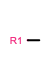
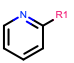
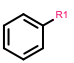
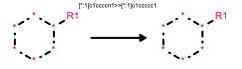
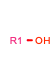
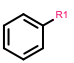
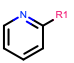
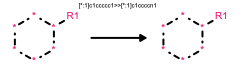
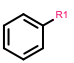
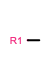
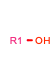
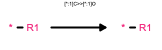
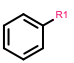
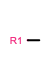
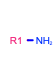
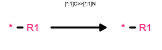
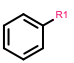
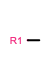
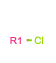
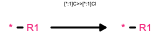
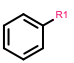
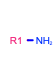
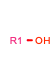
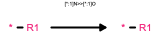
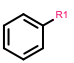
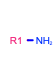
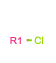
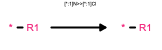
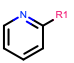
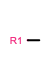
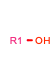
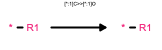

In [4]:
# Subset of the data we'll show in our DataFrame
pair_columns = [
    "source_id",
    "target_id",
    "constant",
    "source_variable",
    "target_variable",
    "transform",
    "pIC50_delta",
]

improving_pairs = analysis.pairs.improves("pIC50")
improving_pairs.to_dataframe(molecules=True)[pair_columns]

## Pairs That Decrease Or Do Not Change Potency

Analogous to `increases()`, the `decreases()` method returns pairs whose target value is lower than the source value, and `unchanged()` returns pairs whose delta is exactly zero.

,source_id,target_id,constant,source_variable,target_variable,transform,pIC50_delta
0,toluene,methyl_pyridine,,,,,-1.0
1,hydroxy_pyridine,phenol,,,,,-1.0
2,phenol,toluene,,,,,-1.0
3,phenol,aniline,,,,,-0.5
4,aniline,toluene,,,,,-0.5
5,chlorophenyl,toluene,,,,,-1.0
6,chlorophenyl,aniline,,,,,-0.5
7,hydroxy_pyridine,methyl_pyridine,,,,,-3.0

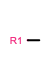
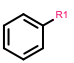
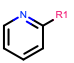
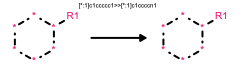
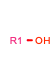
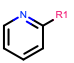
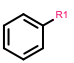
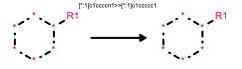
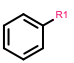
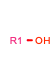
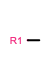
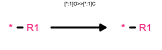
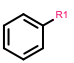
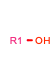
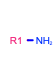
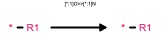
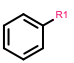
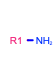
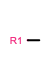
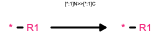
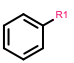
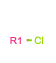
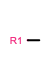
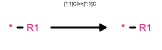
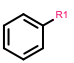
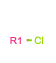
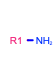
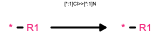
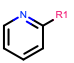
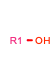
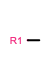
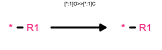

In [5]:
analysis.pairs.decreases("pIC50").to_dataframe(molecules=True)[pair_columns]

,source_id,target_id,constant,source_variable,target_variable,transform,pIC50_delta
0,phenol,chlorophenyl,,,,,0.0
1,chlorophenyl,phenol,,,,,0.0

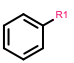
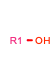
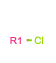
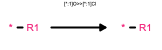
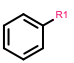
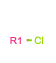
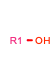
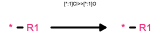

In [6]:
analysis.pairs.unchanged("pIC50").to_dataframe(molecules=True)[pair_columns]

## Filtering Pairs

In case you want to focus on a particular scaffold or change, you can search matched pairs by SMARTS and SMILES. Searches are chainable, meaning you can mix and match multiple `where` queries.

**Example 1: Only show pyridine pairs**

We filter the constant region by the pyridine SMILES, which will only show mathced pairs on the pyridine scaffold.

,source_id,target_id,constant,source_variable,target_variable,transform,pIC50_delta
0,methyl_pyridine,hydroxy_pyridine,,,,,3.0

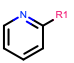
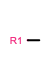
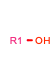
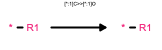

In [7]:
improving_pairs.where_constant_matches("n1ccccc1").to_dataframe(molecules=True)[pair_columns]

**Example 2: Only show methyl to hydroxyl changes**

We combine two queries, one for a methyl in the source molecule and one for a hydroxyl in the target molecule.

,source_id,target_id,constant,source_variable,target_variable,transform,pIC50_delta
0,toluene,phenol,,,,,1.0
1,methyl_pyridine,hydroxy_pyridine,,,,,3.0

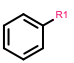
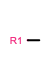
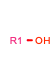
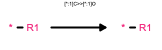
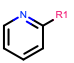
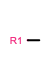
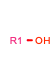
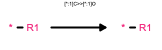

In [8]:
(
    improving_pairs
    .where_from_matches("[CH3]")
    .where_to_matches("[OH]")
    .to_dataframe(molecules=True)[pair_columns]
)

## Frame The Analysis With An Objective

Once we want to start designing molecules, we need to frame our analysis with an objective. This just means indicating a property that we're focused on and a direction that makes that property "better". Note that the property must be loaded on the `AnalysisResult` object already.

Here are different ways to specify an objective:

```python
# Default: Increasing the property is better
# The following are both way to define the same objective
objective = Objective("pIC50")
objective = Objective("pIC50", direction="increase")


# Decreasing the property is better
objective = Objective("cLogP", direction="decrease")
```

Let's create an objective where we want to improve pIC50 for our analysis above. Setting an objective on an `AnalysisResult` creates an `ObjectiveAnalysis` object, which can then be used for design.

In [9]:
objective = Objective("pIC50")
objective_analysis = analysis.objective(objective)

objective_analysis

property,pIC50
direction,increase
aggregation,avg
molecules,6
pairs,18
transforms,14


We can spot check ourselves by looking at the transforms that improve this objective. It should line up with our observations from `analysis.pairs.improves("pIC50")`, but now we've calculated more detailed statistics that and strength of evidence, which will be useful in assessing confidence in our designs.

In [10]:
objective_analysis.transforms.improves().to_dataframe()

,transform,evidence_count,property,predicted_delta,count,std,p_value
0,[*:1]C>>[*:1]O,2,pIC50,2.0,2,1.4142135623730951,0.2951672353008665
1,[*:1]C>>[*:1]Cl,1,pIC50,1.0,1,NaN,NaN
2,[*:1]C>>[*:1]N,1,pIC50,0.5,1,NaN,NaN
3,[*:1]N>>[*:1]Cl,1,pIC50,0.5,1,NaN,NaN
4,[*:1]N>>[*:1]O,1,pIC50,0.5,1,NaN,NaN


## Improving a Novel Molecule

Let's create a novel para-trifluoromethyl-toluene molecule and ask our analysis to generate a potentially better compound. The `objective_analysis.generate()` method applies the improving transforms to our new molecule and returns potential products. The optional `min_evidence` parameter can be used to filter out low-confidence matched pairs.

<oechem.OEGraphMol; proxy of <Swig Object of type 'OEGraphMolWrapper *' at 0x168e5cf00> >
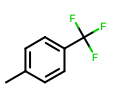

In [11]:
mol = oechem.OEGraphMol()
oechem.OESmilesToMol(mol, "Cc1ccc(cc1)C(F)(F)F")

mol

,smiles,transform,evidence_count,is_known_product,known_product_ids,property,predicted_delta,count,std,p_value
0,,,2,False,[],pIC50,2.0,2,1.4142135623730951,0.2951672353008665

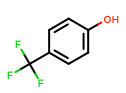
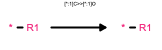

In [12]:
products = objective_analysis.generate(mol, min_evidence=2)
products.to_dataframe(molecules=True)

Looking back at our transforms, we see `[*:1]C>>[*:1]O` was observed to predict potency, so that is exactly the transform applied here.

## Ask What Could Improve A Specific Molecule

`opportunities()` answers the molecule-level question: given everything we have learned, what should we make next? It reports three things:

* `rules` — applicable transforms with their statistics.
* `pairs` — observed matched pairs that support those rules. For an indexed source, these are the molecule's outgoing pairs; for a novel source, these are the supporting evidence pairs from the dataset.
* `products` — generated products with predicted deltas and a flag indicating whether each product already exists in the analyzed dataset.

The summary at the top counts the rules, pairs, and products. Increasing `min_evidence` keeps only the most strongly supported suggestions. Let's use a more complicated molecule in this example.

<oechem.OEGraphMol; proxy of <Swig Object of type 'OEGraphMolWrapper *' at 0x1694154a0> >
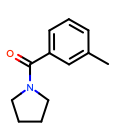

In [13]:
new_compound = oechem.OEGraphMol()
oechem.OESmilesToMol(new_compound, "Cc1cccc(c1)C(=O)N2CCCC2")

new_compound

In [14]:
opportunities = objective_analysis.opportunities(new_compound, min_evidence=2)
opportunities

OpportunityResult(molecule_id="<oechem.OEGraphMol; proxy of <Swig Object of type 'OEGraphMolWrapper *' at 0x1694154a0> >", source_smiles='Cc1cccc(c1)C(=O)N2CCCC2', rules=1, pairs=2, products=1)

,transform,evidence_count,property,predicted_delta,count,std,p_value
0,,2,pIC50,2.0,2,1.4142135623730951,0.2951672353008665

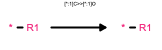

In [15]:
opportunities.rules.to_dataframe(molecules=True)

,source_id,target_id,constant,source_variable,target_variable,transform,cut_count,heavy_atom_delta,heavy_bond_delta,pIC50_delta
0,toluene,phenol,,,,,1,0,0,1.0
1,methyl_pyridine,hydroxy_pyridine,,,,,1,0,0,3.0

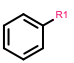
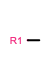
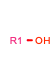
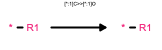
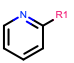
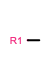
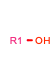
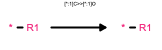

In [16]:
opportunities.pairs.to_dataframe(molecules=True)

,smiles,transform,evidence_count,is_known_product,known_product_ids,property,predicted_delta,count,std,p_value
0,,,2,False,[],pIC50,2.0,2,1.4142135623730951,0.2951672353008665

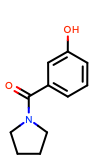
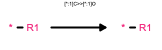

In [17]:
opportunities.products.to_dataframe(molecules=True)

## Where To Next

* See [`docs/python-api.md`](../docs/python-api.md) for the full Python API including `save()` / `oemmpa.open()`, `Selection`, and the rule-environment helpers.
* See [`docs/cli.md`](../docs/cli.md) for the file-based `oemmpa` command-line workflow.
* Result objects expose `to_dicts()` and `to_dataframe()` (with optional `library="polars"`) for downstream processing in any pandas- or polars-friendly pipeline.